# Classical preprocessing experiments

In [18]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths

PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "sdnet2018"

SURFACES = ["deck", "pavement", "wall"]

random.seed(42)


# Get cracked images

def get_cracked_images(surface):
    folder = DATASET_DIR / surface / "crack_dataset"

    return [
        p for p in folder.rglob("*")
        if p.is_file()
        and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]


# Preprocessing and segmentation

def process_image(image):

    # Convert BGR → RGB for display
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Mild noise reduction
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Local contrast enhancement
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(blurred)

    # Method 1: Otsu thresholding

    _, otsu = cv2.threshold(
        enhanced,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Method 2: Adaptive thresholding
    adaptive = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        21,
        5
    )
    # Method 3: Black-hat morphological enhancement

    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (15, 15)
    )

    blackhat = cv2.morphologyEx(
        plt.gray,
        cv2.MORPH_BLACKHAT,
        kernel
    )

    _, blackhat_mask = cv2.threshold(
        blackhat,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return rgb, gray, enhanced, otsu, adaptive, blackhat, blackhat_mask


# Inspect one image from each surface

for surface in SURFACES:

    images = get_cracked_images(surface)

    selected = random.choice(images)

    image = cv2.imread(str(selected))

    if image is None:
        print(f"Could not read: {selected}")
        continue

    (
        rgb,
        gray,
        enhanced,
        otsu,
        adaptive,
        blackhat,
        blackhat_mask
    ) = process_image(image)

    print(f"{surface.upper()}")
    print(f"Image: {selected.name}")
    print()

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title("Original RGB")

    axes[0, 1].imshow(gray, cmap="gray")
    axes[0, 1].set_title("Grayscale")

    axes[0, 2].imshow(enhanced, cmap="gray")
    axes[0, 2].set_title("CLAHE")

    axes[0, 3].imshow(blackhat, cmap="gray")
    axes[0, 3].set_title("Black-hat Enhancement")

    axes[1, 0].imshow(otsu, cmap="gray")
    axes[1, 0].set_title("Otsu Mask")

    axes[1, 1].imshow(adaptive, cmap="gray")
    axes[1, 1].set_title("Adaptive Threshold Mask")

    axes[1, 2].imshow(blackhat_mask, cmap="gray")
    axes[1, 2].set_title("Black-hat + Otsu Mask")

    # Overlay black-hat mask on original image
    overlay = rgb.copy()
    mask = blackhat_mask > 0
    overlay[mask] = [255, 0, 0]

    axes[1, 3].imshow(overlay)
    axes[1, 3].set_title("Black-hat Mask Overlay")

    for ax in axes.flat:
        ax.axis("off")

    fig.suptitle(
        f"SDNET2018 Segmentation Inspection — {surface.capitalize()}",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

error: OpenCV(5.0.0) :-1: error: (-5:Bad argument) in function 'morphologyEx'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'


### directional filtering and connected-component filtering

Surface: deck
Image: 7033-188.jpg
Threshold: 134.00


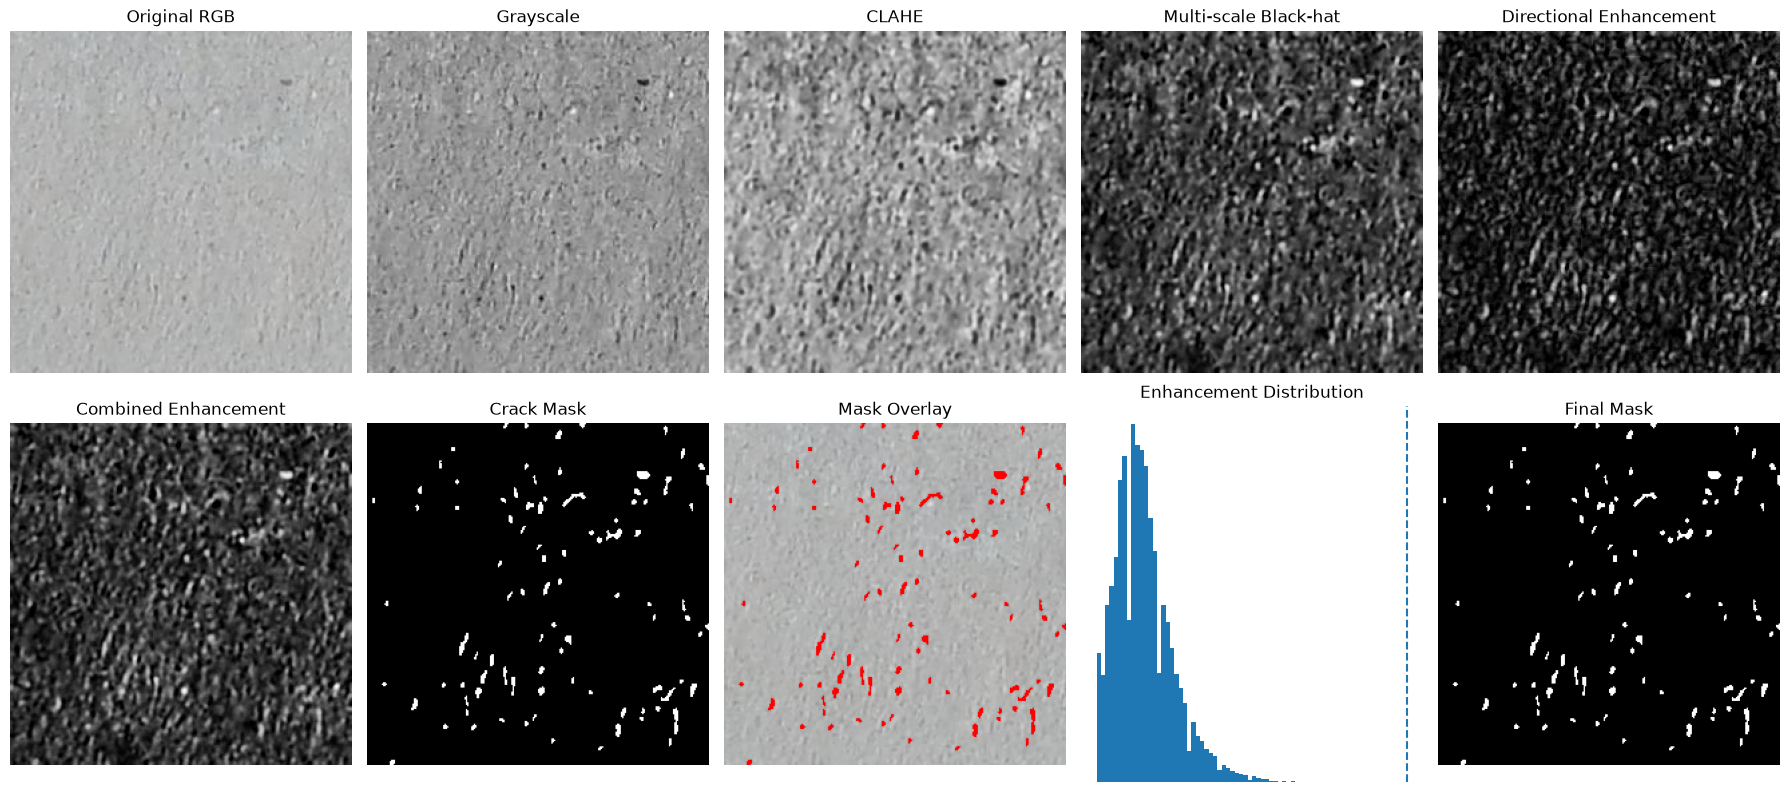

Surface: pavement
Image: 019-84.jpg
Threshold: 191.00


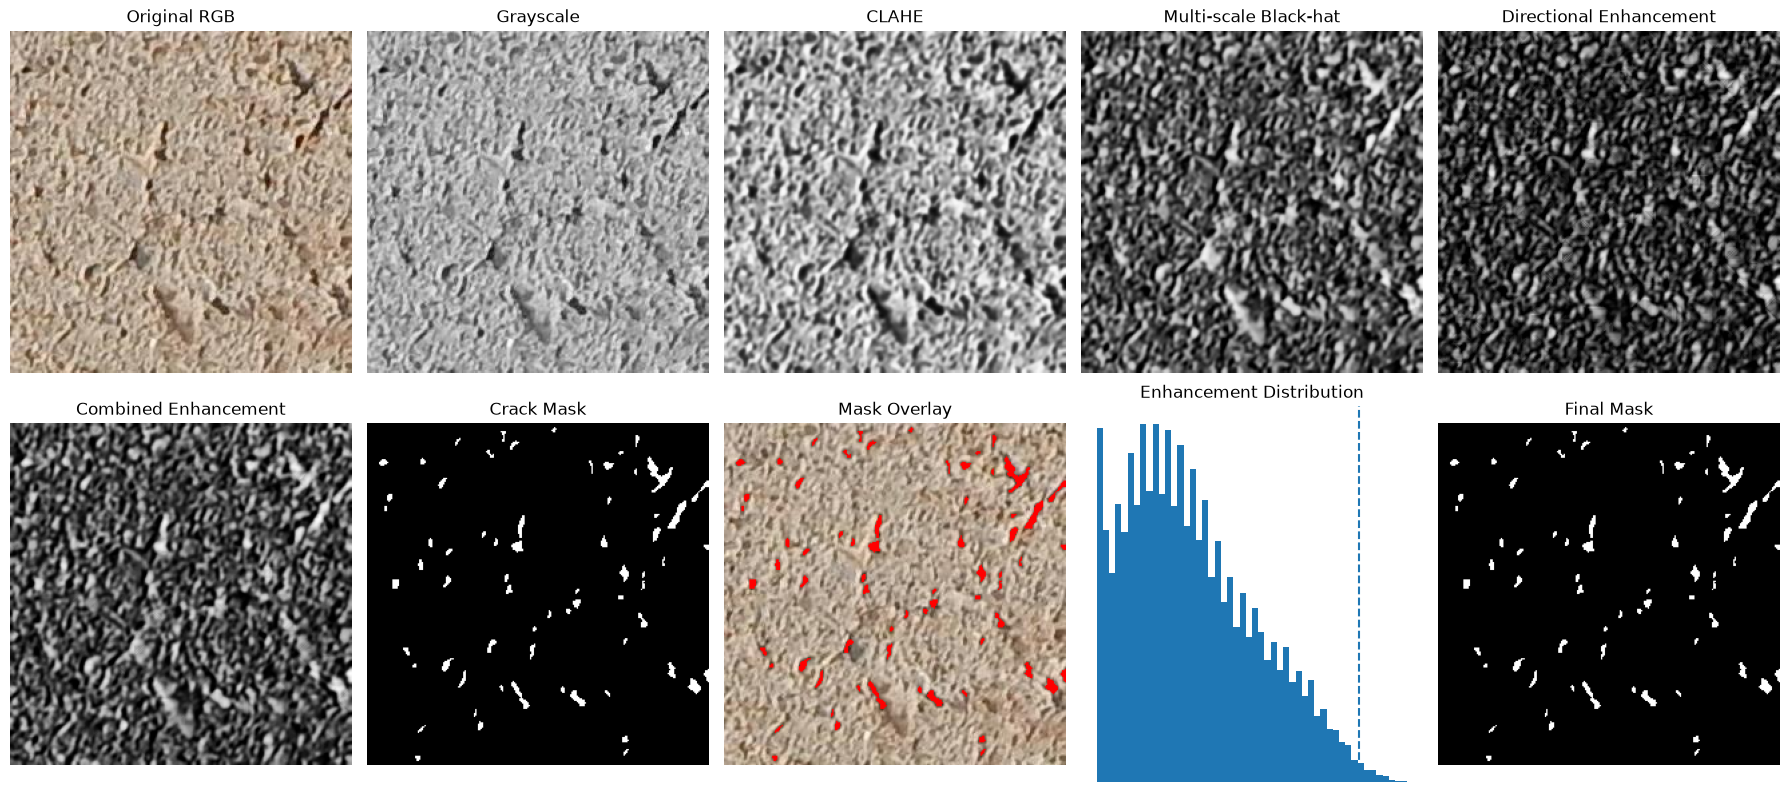

Surface: wall
Image: 7069-90.jpg
Threshold: 74.00


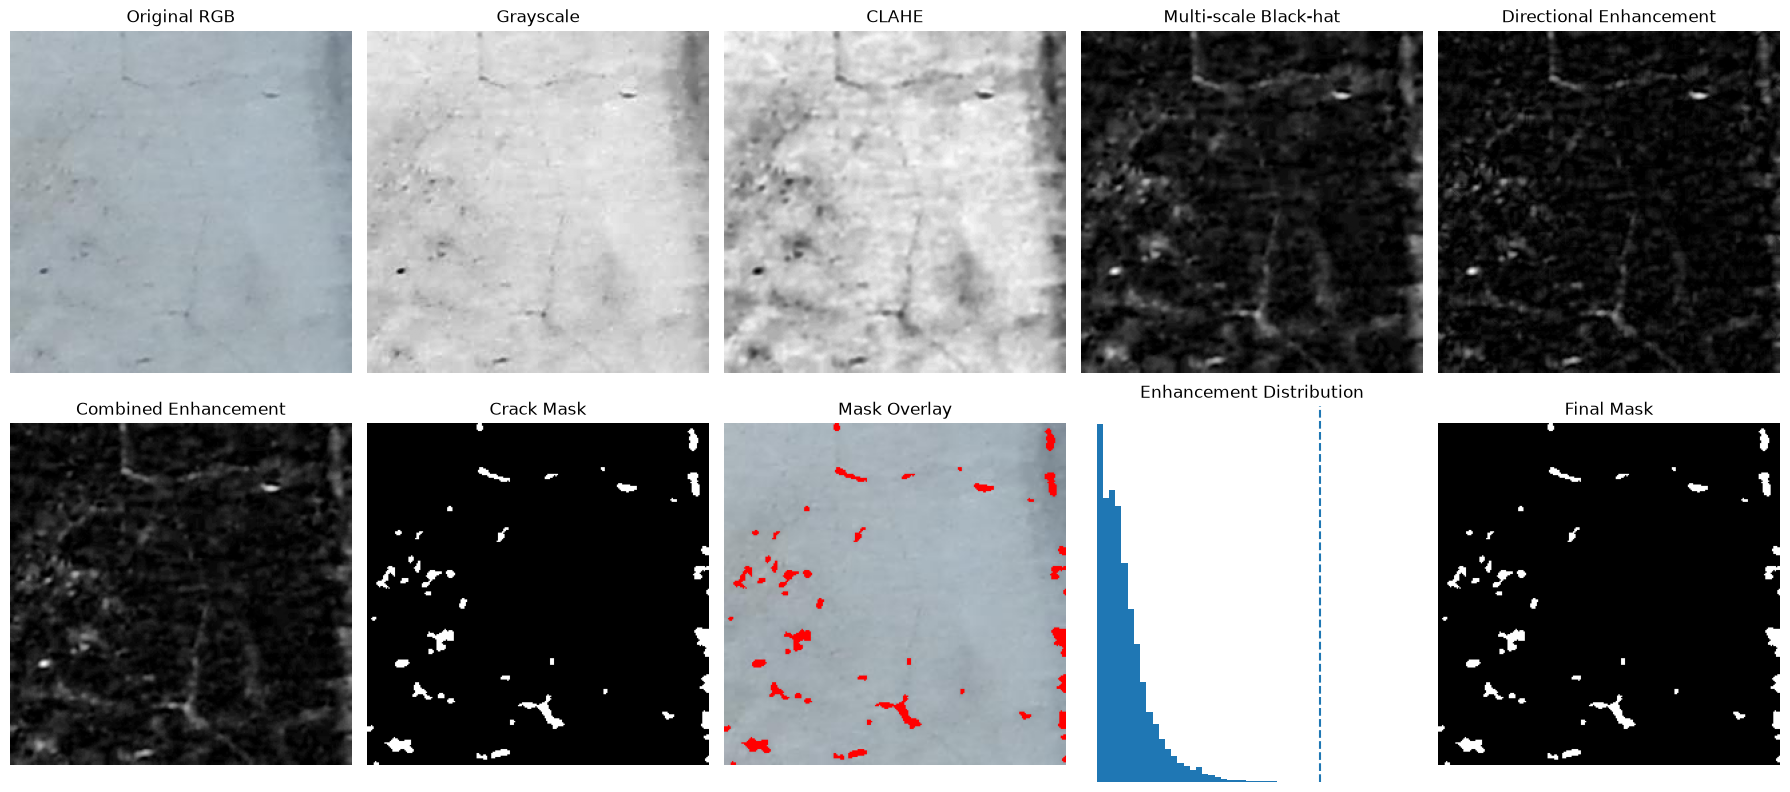

In [6]:
from pathlib import Path
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "sdnet2018"

SURFACES = ["deck", "pavement", "wall"]

random.seed(42)


# Get cracked images
def get_cracked_images(surface):
    folder = DATASET_DIR / surface / "crack_dataset"

    images = [
        p for p in folder.rglob("*")
        if p.is_file()
        and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]

    return sorted(images)


# Create directional line kernel
def line_kernel(length, angle):

    kernel = np.zeros((length, length), dtype=np.uint8)

    center = length // 2
    angle_rad = np.deg2rad(angle)

    dx = int(np.cos(angle_rad) * center)
    dy = int(np.sin(angle_rad) * center)

    x1 = center - dx
    y1 = center - dy
    x2 = center + dx
    y2 = center + dy

    cv2.line(
        kernel,
        (x1, y1),
        (x2, y2),
        1,
        1
    )

    return kernel


# Crack enhancement
def crack_enhancement(image):

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian smoothing
    smooth = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    # Apply CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    enhanced = clahe.apply(smooth)

    # Apply multi-scale black-hat
    blackhat_small = cv2.morphologyEx(
        enhanced,
        cv2.MORPH_BLACKHAT,
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (11, 11)
        )
    )

    blackhat_medium = cv2.morphologyEx(
        enhanced,
        cv2.MORPH_BLACKHAT,
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (21, 21)
        )
    )

    blackhat_large = cv2.morphologyEx(
        enhanced,
        cv2.MORPH_BLACKHAT,
        cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (31, 31)
        )
    )

    # Combine scales
    blackhat = np.maximum.reduce([
        blackhat_small,
        blackhat_medium,
        blackhat_large
    ])

    # Apply directional filters
    directional_responses = []

    for angle in [0, 45, 90, 135]:

        kernel = line_kernel(15, angle)

        response = cv2.morphologyEx(
            enhanced,
            cv2.MORPH_BLACKHAT,
            kernel
        )

        directional_responses.append(response)

    directional = np.maximum.reduce(
        directional_responses
    )

    # Combine black-hat and directional responses
    combined = cv2.addWeighted(
        blackhat,
        0.6,
        directional,
        0.4,
        0
    )

    return (
        gray,
        smooth,
        enhanced,
        blackhat,
        directional,
        combined
    )


# Create crack mask
def create_crack_mask(enhanced_image):

    # Normalize enhancement
    normalized = cv2.normalize(
        enhanced_image,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    # Use a high percentile threshold
    threshold_value = np.percentile(
        normalized,
        97
    )

    mask = (
        normalized >= threshold_value
    ).astype(np.uint8) * 255

    # Remove small components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    cleaned = np.zeros_like(mask)

    min_area = 8

    for label in range(1, num_labels):

        area = stats[label, cv2.CC_STAT_AREA]

        if area >= min_area:
            cleaned[labels == label] = 255

    # Connect nearby crack segments
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    cleaned = cv2.morphologyEx(
        cleaned,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=1
    )

    return cleaned, threshold_value


# Display results
for surface in SURFACES:

    images = get_cracked_images(surface)

    if not images:
        print(f"No images found for {surface}.")
        continue

    selected = random.choice(images)

    image = cv2.imread(str(selected))

    if image is None:
        print(f"Could not read: {selected}")
        continue

    (
        gray,
        smooth,
        enhanced,
        blackhat,
        directional,
        combined
    ) = crack_enhancement(image)

    mask, threshold_value = create_crack_mask(
        combined
    )

    rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Create overlay
    overlay = rgb.copy()
    overlay[mask > 0] = [255, 0, 0]

    print(f"Surface: {surface}")
    print(f"Image: {selected.name}")
    print(f"Threshold: {threshold_value:.2f}")

    # Display results
    fig, axes = plt.subplots(
        2,
        5,
        figsize=(18, 8)
    )

    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title("Original RGB")

    axes[0, 1].imshow(gray, cmap="gray")
    axes[0, 1].set_title("Grayscale")

    axes[0, 2].imshow(enhanced, cmap="gray")
    axes[0, 2].set_title("CLAHE")

    axes[0, 3].imshow(blackhat, cmap="gray")
    axes[0, 3].set_title("Multi-scale Black-hat")

    axes[0, 4].imshow(directional, cmap="gray")
    axes[0, 4].set_title("Directional Enhancement")

    axes[1, 0].imshow(combined, cmap="gray")
    axes[1, 0].set_title("Combined Enhancement")

    axes[1, 1].imshow(
        mask,
        cmap="gray"
    )
    axes[1, 1].set_title("Crack Mask")

    axes[1, 2].imshow(overlay)
    axes[1, 2].set_title("Mask Overlay")

    axes[1, 3].hist(
        combined.ravel(),
        bins=50
    )
    axes[1, 3].axvline(
        threshold_value,
        linestyle="--"
    )
    axes[1, 3].set_title("Enhancement Distribution")

    axes[1, 4].imshow(
        mask,
        cmap="gray"
    )
    axes[1, 4].set_title("Final Mask")

    for ax in axes.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### the Canny + shape-filtering experiment

Surface: deck
Image: 7033-188.jpg


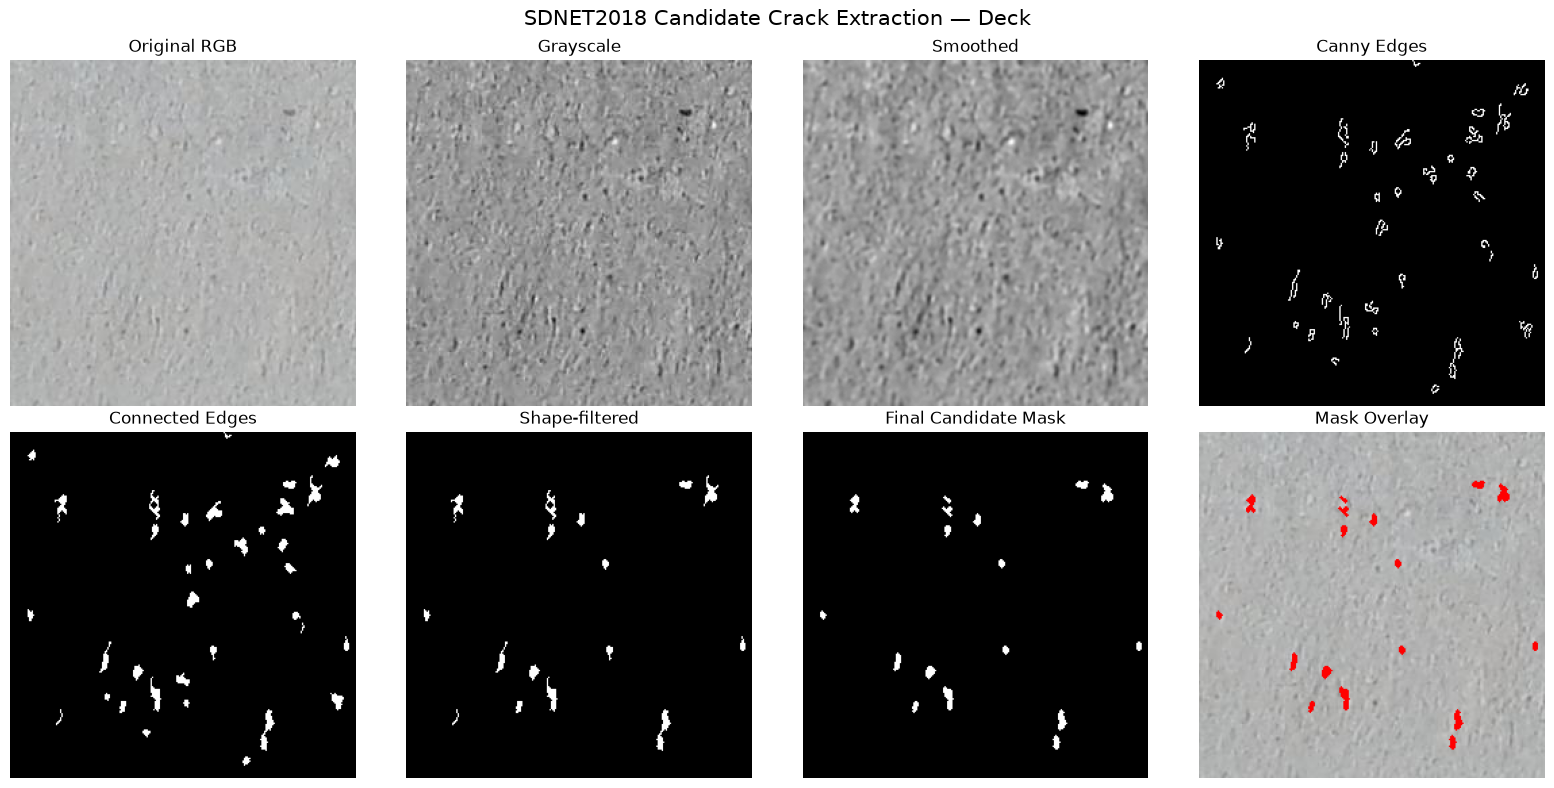

Surface: pavement
Image: 019-84.jpg


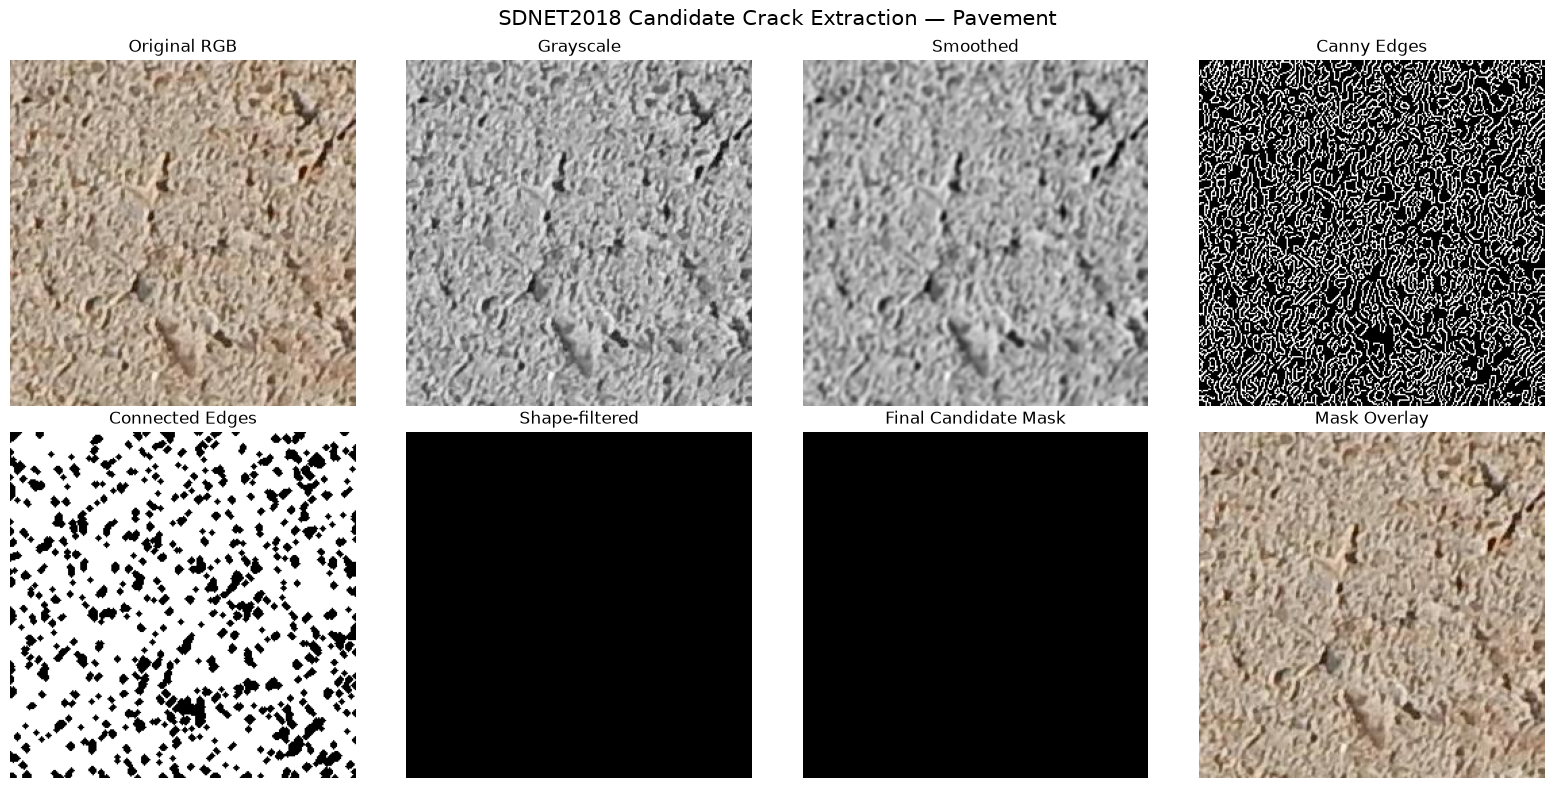

Surface: wall
Image: 7069-90.jpg


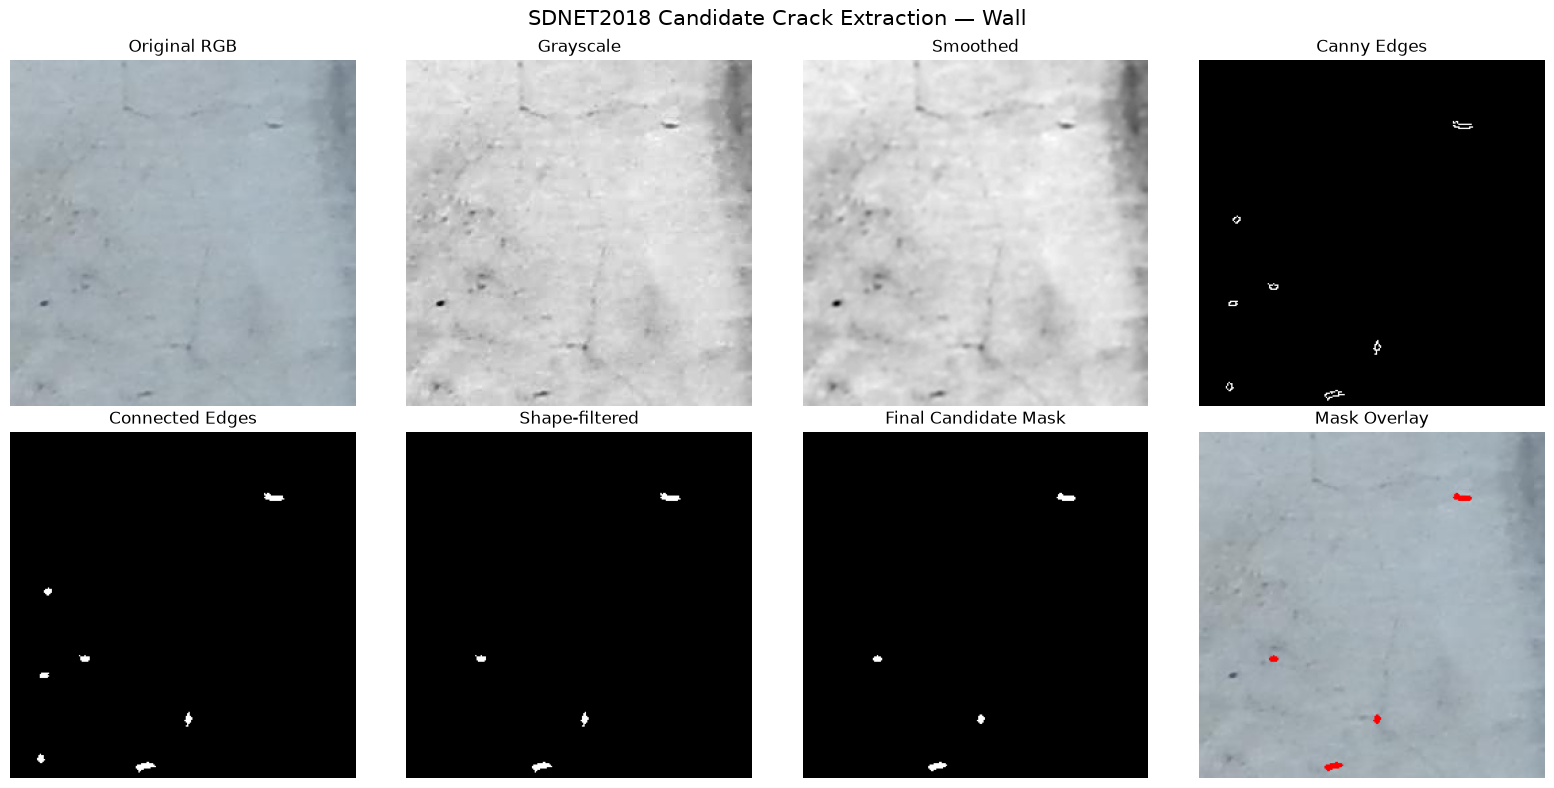

In [7]:
from pathlib import Path
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "sdnet2018"

SURFACES = ["deck", "pavement", "wall"]

random.seed(42)


# Get cracked images
def get_cracked_images(surface):
    folder = DATASET_DIR / surface / "crack_dataset"

    images = [
        p for p in folder.rglob("*")
        if p.is_file()
        and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]

    return sorted(images)


# Detect candidate crack features
def detect_crack_candidates(image):

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Reduce noise
    smooth = cv2.GaussianBlur(
        gray,
        (5, 5),
        0
    )

    # Detect edges
    edges = cv2.Canny(
        smooth,
        40,
        100
    )

    # Connect nearby edge segments
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    connected = cv2.morphologyEx(
        edges,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    return gray, smooth, edges, connected


# Filter components based on shape
def filter_crack_components(mask):

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        mask,
        connectivity=8
    )

    filtered = np.zeros_like(mask)

    min_area = 10
    min_length = 8

    for label in range(1, num_labels):

        area = stats[label, cv2.CC_STAT_AREA]
        width = stats[label, cv2.CC_STAT_WIDTH]
        height = stats[label, cv2.CC_STAT_HEIGHT]

        if area < min_area:
            continue

        major_dimension = max(width, height)
        minor_dimension = min(width, height)

        # Calculate elongation
        elongation = major_dimension / max(
            minor_dimension,
            1
        )

        # Retain elongated or sufficiently long components
        if (
            major_dimension >= min_length
            and elongation >= 1.5
        ):
            filtered[labels == label] = 255

    return filtered


# Create candidate crack mask
def create_crack_mask(image):

    gray, smooth, edges, connected = detect_crack_candidates(
        image
    )

    filtered = filter_crack_components(
        connected
    )

    # Remove small isolated features
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    cleaned = cv2.morphologyEx(
        filtered,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    return gray, smooth, edges, connected, filtered, cleaned


# Display results
for surface in SURFACES:

    images = get_cracked_images(surface)

    if not images:
        print(f"No images found for {surface}.")
        continue

    selected = random.choice(images)

    image = cv2.imread(
        str(selected)
    )

    if image is None:
        print(f"Could not read: {selected}")
        continue

    (
        gray,
        smooth,
        edges,
        connected,
        filtered,
        cleaned
    ) = create_crack_mask(image)

    rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Create overlay
    overlay = rgb.copy()
    overlay[cleaned > 0] = [255, 0, 0]

    print(f"Surface: {surface}")
    print(f"Image: {selected.name}")

    # Display results
    fig, axes = plt.subplots(
        2,
        4,
        figsize=(16, 8)
    )

    axes[0, 0].imshow(rgb)
    axes[0, 0].set_title("Original RGB")

    axes[0, 1].imshow(
        gray,
        cmap="gray"
    )
    axes[0, 1].set_title("Grayscale")

    axes[0, 2].imshow(
        smooth,
        cmap="gray"
    )
    axes[0, 2].set_title("Smoothed")

    axes[0, 3].imshow(
        edges,
        cmap="gray"
    )
    axes[0, 3].set_title("Canny Edges")

    axes[1, 0].imshow(
        connected,
        cmap="gray"
    )
    axes[1, 0].set_title("Connected Edges")

    axes[1, 1].imshow(
        filtered,
        cmap="gray"
    )
    axes[1, 1].set_title("Shape-filtered")

    axes[1, 2].imshow(
        cleaned,
        cmap="gray"
    )
    axes[1, 2].set_title("Final Candidate Mask")

    axes[1, 3].imshow(
        overlay
    )
    axes[1, 3].set_title("Mask Overlay")

    for ax in axes.flat:
        ax.axis("off")

    plt.suptitle(
        f"SDNET2018 Candidate Crack Extraction — {surface.capitalize()}",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

## Crack Morphology

In [8]:
# Create skeleton from binary mask
def skeletonize_mask(mask):

    binary = (mask > 0).astype(np.uint8) * 255
    skeleton = np.zeros_like(binary)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_CROSS,
        (3, 3)
    )

    while True:

        eroded = cv2.erode(
            binary,
            kernel
        )

        opened = cv2.morphologyEx(
            eroded,
            cv2.MORPH_OPEN,
            kernel
        )

        difference = cv2.subtract(
            eroded,
            opened
        )

        skeleton = cv2.bitwise_or(
            skeleton,
            difference
        )

        binary = eroded.copy()

        if cv2.countNonZero(binary) == 0:
            break

    return skeleton


# Calculate skeleton length
def calculate_skeleton_length(skeleton):

    binary = skeleton > 0
    height, width = binary.shape

    length = 0.0

    for y in range(height):
        for x in range(width):

            if not binary[y, x]:
                continue

            # Horizontal connection
            if x + 1 < width and binary[y, x + 1]:
                length += 1.0

            # Vertical connection
            if y + 1 < height and binary[y + 1, x]:
                length += 1.0

            # Diagonal connection
            if (
                x + 1 < width
                and y + 1 < height
                and binary[y + 1, x + 1]
            ):
                length += np.sqrt(2)

            # Other diagonal connection
            if (
                x - 1 >= 0
                and y + 1 < height
                and binary[y + 1, x - 1]
            ):
                length += np.sqrt(2)

    return length


# Calculate crack width
def calculate_crack_width(mask, skeleton):

    binary_mask = (mask > 0).astype(np.uint8)

    distance = cv2.distanceTransform(
        binary_mask,
        cv2.DIST_L2,
        5
    )

    skeleton_points = skeleton > 0

    widths = (
        2 * distance[skeleton_points]
    )

    widths = widths[widths > 0]

    if len(widths) == 0:
        return np.nan, np.nan

    return (
        float(np.mean(widths)),
        float(np.max(widths))
    )


# Calculate dominant orientation
def calculate_orientation(skeleton):

    y, x = np.where(skeleton > 0)

    if len(x) < 2:
        return np.nan

    coordinates = np.column_stack(
        (x, y)
    ).astype(float)

    coordinates -= coordinates.mean(
        axis=0
    )

    covariance = np.cov(
        coordinates,
        rowvar=False
    )

    eigenvalues, eigenvectors = np.linalg.eigh(
        covariance
    )

    direction = eigenvectors[
        :, np.argmax(eigenvalues)
    ]

    angle = np.degrees(
        np.arctan2(
            direction[1],
            direction[0]
        )
    )

    # Convert to 0–180 degrees
    angle = angle % 180

    return float(angle)


# Calculate branch points
def calculate_branch_points(skeleton):

    binary = (
        skeleton > 0
    ).astype(np.uint8)

    kernel = np.array([
        [1, 1, 1],
        [1, 0, 1],
        [1, 1, 1]
    ], dtype=np.uint8)

    neighbours = cv2.filter2D(
        binary,
        -1,
        kernel
    )

    # Detect possible branch pixels
    branch_pixels = (
        (binary == 1)
        & (neighbours >= 3)
    ).astype(np.uint8)

    # Group neighbouring branch pixels
    branch_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (3, 3)
    )

    branch_pixels = cv2.dilate(
        branch_pixels,
        branch_kernel,
        iterations=1
    )

    num_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            branch_pixels,
            connectivity=8
        )
    )

    branch_points = 0

    for label in range(1, num_labels):

        area = stats[
            label,
            cv2.CC_STAT_AREA
        ]

        if area >= 1:
            branch_points += 1

    return branch_points


# Extract morphology features
def extract_morphology(mask):

    skeleton = skeletonize_mask(
        mask
    )

    total_pixels = mask.shape[0] * mask.shape[1]

    crack_pixels = np.count_nonzero(
        mask
    )

    area_ratio = (
        crack_pixels
        / total_pixels
        * 100
    )

    length = calculate_skeleton_length(
        skeleton
    )

    mean_width, max_width = (
        calculate_crack_width(
            mask,
            skeleton
        )
    )

    orientation = calculate_orientation(
        skeleton
    )

    branch_points = calculate_branch_points(
        skeleton
    )

    return {
        "area_percent": area_ratio,
        "length_pixels": length,
        "mean_width_pixels": mean_width,
        "max_width_pixels": max_width,
        "dominant_orientation_deg": orientation,
        "branch_points": branch_points,
        "skeleton": skeleton
    }


# Select a small sample
sample_records = []

for surface in SURFACES:

    images = get_cracked_images(
        surface
    )

    selected = random.sample(
        images,
        min(2, len(images))
    )

    for image_path in selected:

        sample_records.append({
            "surface": surface,
            "image_path": image_path
        })


# Extract morphology features
results = []

for record in sample_records:

    image = cv2.imread(
        str(record["image_path"])
    )

    if image is None:
        continue

    (
        gray,
        smooth,
        edges,
        connected,
        filtered,
        cleaned
    ) = create_crack_mask(
        image
    )

    morphology = extract_morphology(
        cleaned
    )

    results.append({
        "surface": record["surface"],
        "image": record["image_path"].name,
        "area_percent": morphology["area_percent"],
        "length_pixels": morphology["length_pixels"],
        "mean_width_pixels": morphology["mean_width_pixels"],
        "max_width_pixels": morphology["max_width_pixels"],
        "dominant_orientation_deg": morphology[
            "dominant_orientation_deg"
        ],
        "branch_points": morphology[
            "branch_points"
        ]
    })


morphology_results = pd.DataFrame(
    results
)

morphology_results

,surface,image,area_percent,length_pixels,mean_width_pixels,max_width_pixels,dominant_orientation_deg,branch_points
0,deck,7039-158.jpg,3.498840,692.707720,4.334723,8.3938,6.126379,41
1,deck,7015-147.jpg,0.979614,302.534055,4.448951,7.1938,164.891376,11
2,pavement,043-85.jpg,0.000000,0.000000,NaN,NaN,NaN,0
3,pavement,040-69.jpg,0.000000,0.000000,NaN,NaN,NaN,0
4,wall,7077-209.jpg,2.146912,750.121933,4.121416,7.1938,111.568793,27
5,wall,7119-158.jpg,1.208496,321.676190,4.426262,10.7876,161.893246,10


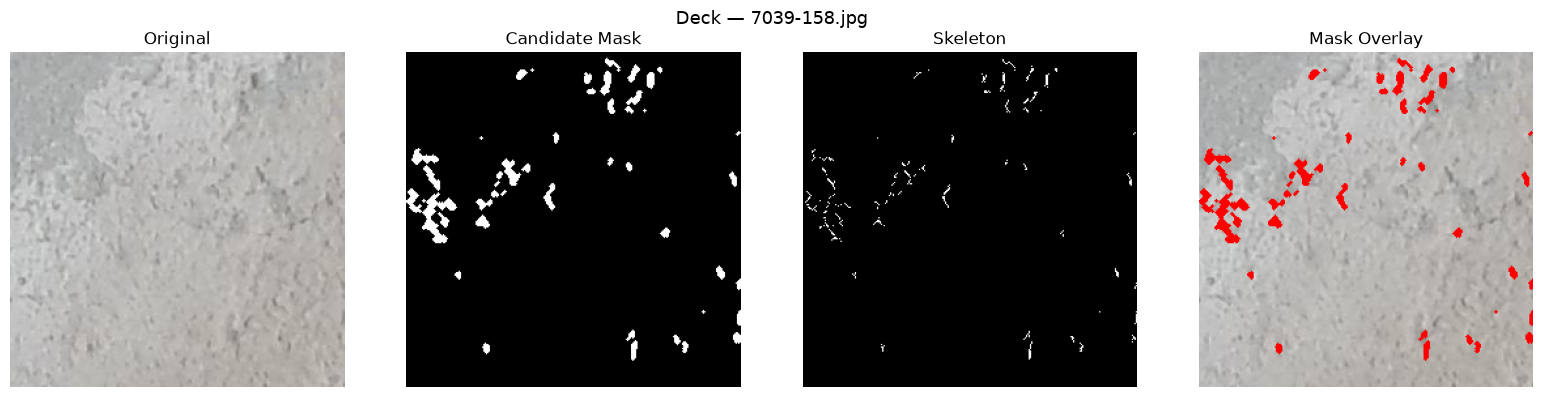

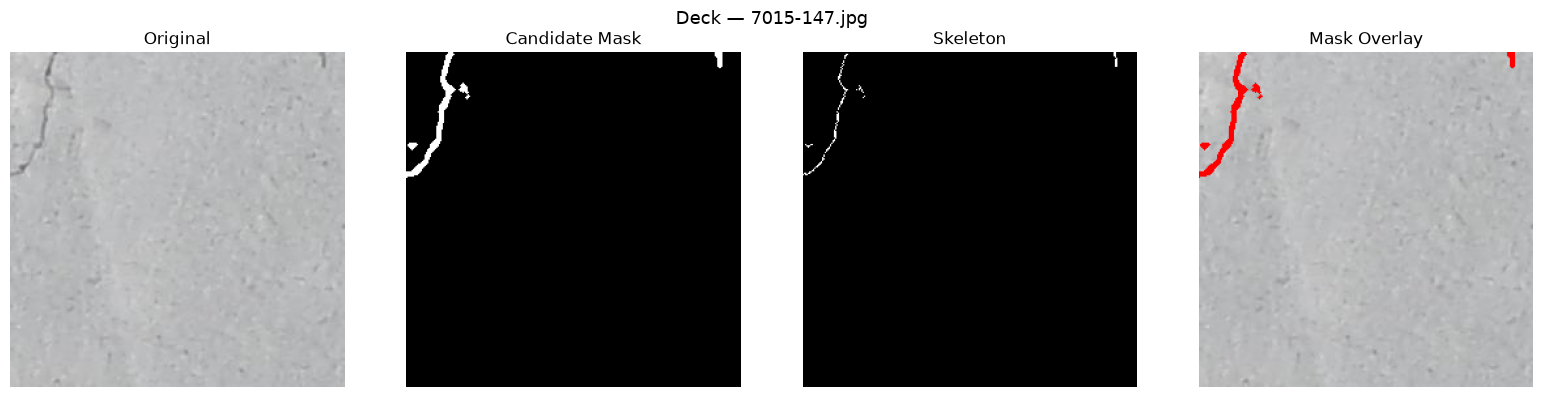

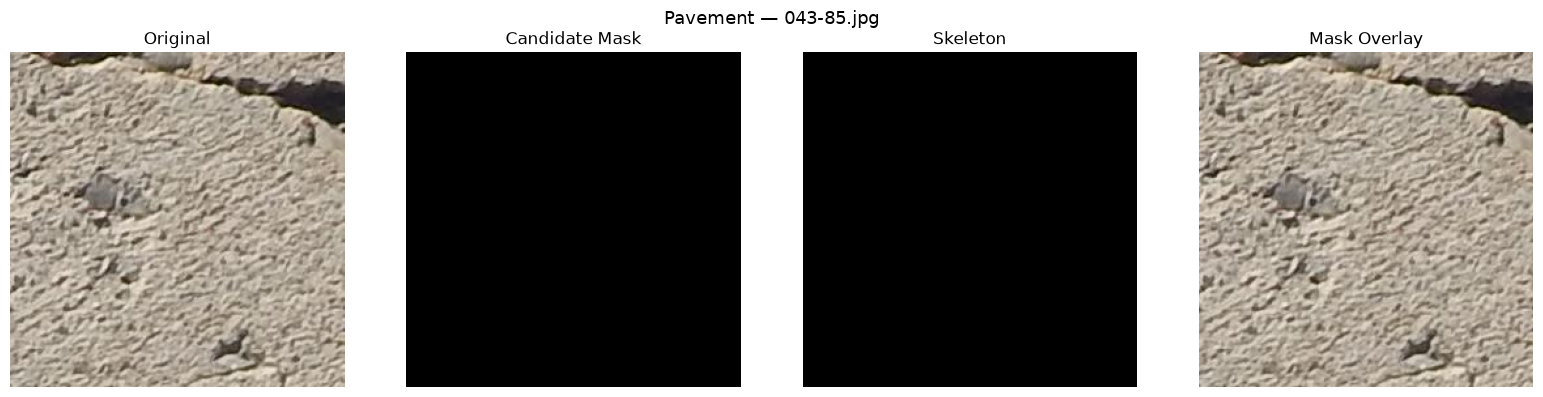

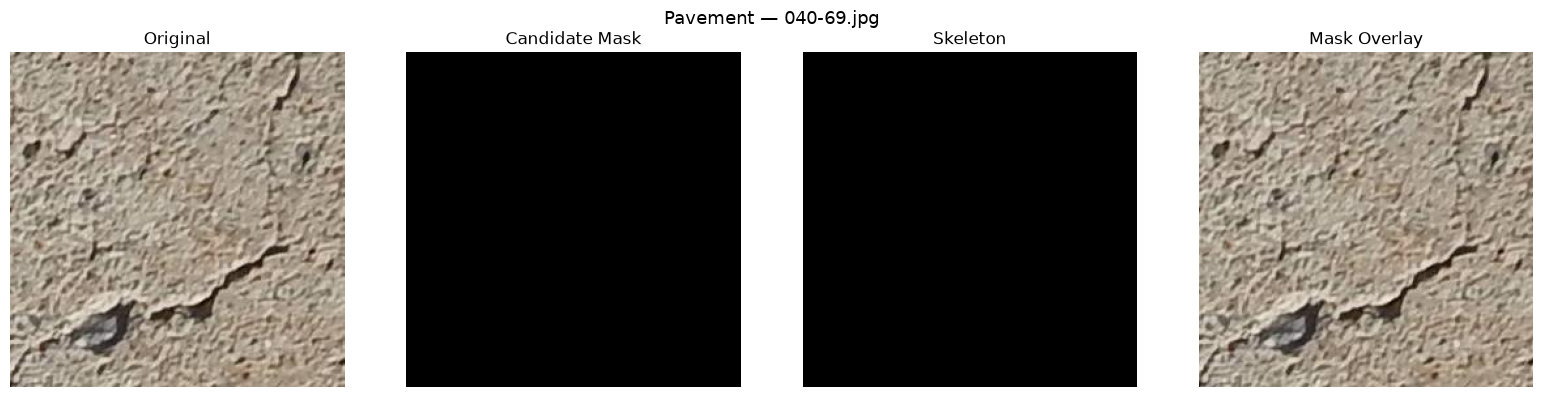

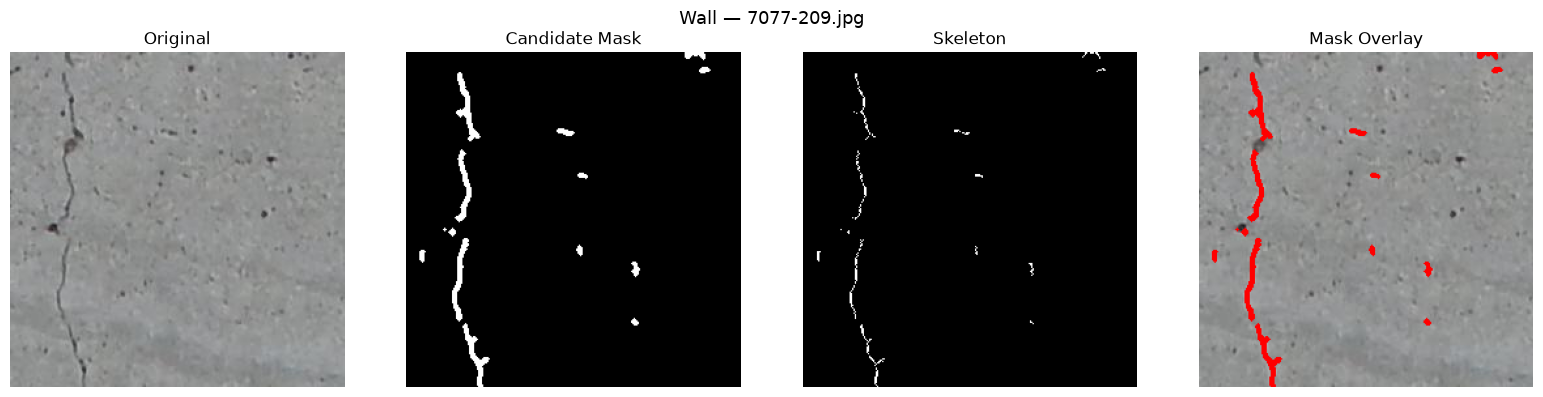

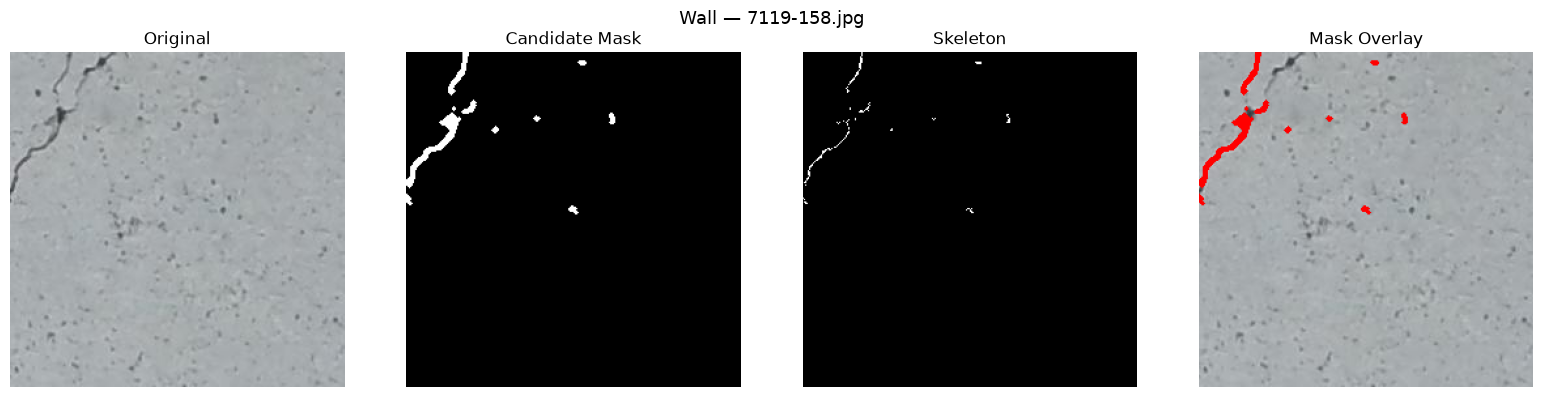

In [9]:
# Display morphology results
for record in sample_records:

    image = cv2.imread(
        str(record["image_path"])
    )

    if image is None:
        continue

    (
        gray,
        smooth,
        edges,
        connected,
        filtered,
        cleaned
    ) = create_crack_mask(
        image
    )

    morphology = extract_morphology(
        cleaned
    )

    rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    skeleton = morphology["skeleton"]

    overlay = rgb.copy()
    overlay[cleaned > 0] = [255, 0, 0]

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(16, 4)
    )

    axes[0].imshow(rgb)
    axes[0].set_title("Original")

    axes[1].imshow(
        cleaned,
        cmap="gray"
    )
    axes[1].set_title("Candidate Mask")

    axes[2].imshow(
        skeleton,
        cmap="gray"
    )
    axes[2].set_title("Skeleton")

    axes[3].imshow(overlay)
    axes[3].set_title("Mask Overlay")

    for ax in axes:
        ax.axis("off")

    plt.suptitle(
        f'{record["surface"].capitalize()} — '
        f'{record["image_path"].name}',
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

# Dataset verification

In [10]:
from pathlib import Path
from PIL import Image
import pandas as pd

# Set dataset path
DATA_DIR = Path("../data/raw/sdnet2018")

# Check dataset structure
for surface in ["deck", "pavement", "wall"]:
    print(f"\n{surface.upper()}")
    
    for label in ["crack_dataset", "uncrack_dataset"]:
        folder = DATA_DIR / surface / label
        images = list(folder.glob("*.jpg"))
        print(f"{label}: {len(images)} images")


DECK
crack_dataset: 2025 images
uncrack_dataset: 11595 images

PAVEMENT
crack_dataset: 2608 images
uncrack_dataset: 21726 images

WALL
crack_dataset: 3851 images
uncrack_dataset: 14287 images


# Image-quality exploration

In [11]:
# Check image properties

sample_images = []

for surface in ["deck", "pavement", "wall"]:
    for label in ["crack_dataset", "uncrack_dataset"]:
        folder = DATA_DIR / surface / label
        images = list(folder.glob("*.jpg"))
        
        if images:
            sample_images.append((surface, label, images[0]))

for surface, label, image_path in sample_images:
    with Image.open(image_path) as img:
        print(
            f"{surface:10} | "
            f"{label:15} | "
            f"size={img.size} | "
            f"mode={img.mode}"
        )

deck       | crack_dataset   | size=(256, 256) | mode=RGB
deck       | uncrack_dataset | size=(256, 256) | mode=RGB
pavement   | crack_dataset   | size=(256, 256) | mode=RGB
pavement   | uncrack_dataset | size=(256, 256) | mode=RGB
wall       | crack_dataset   | size=(256, 256) | mode=RGB
wall       | uncrack_dataset | size=(256, 256) | mode=RGB


In [12]:
# Create image metadata

records = []

for surface in ["deck", "pavement", "wall"]:
    for folder_name, label, class_id in [
        ("crack_dataset", "cracked", 1),
        ("uncrack_dataset", "uncracked", 0)
    ]:
        
        folder = DATA_DIR / surface / folder_name
        
        for image_path in folder.glob("*.jpg"):
            records.append({
                "image_path": str(image_path),
                "surface": surface,
                "label": label,
                "class_id": class_id
            })

metadata = pd.DataFrame(records)

print("Total images:", len(metadata))
print("\nClass distribution:")
print(metadata["label"].value_counts())

print("\nSurface distribution:")
print(metadata["surface"].value_counts())

metadata.head()

Total images: 56092

Class distribution:
label
uncracked    47608
cracked       8484
Name: count, dtype: int64

Surface distribution:
surface
pavement    24334
wall        18138
deck        13620
Name: count, dtype: int64


,image_path,surface,label,class_id
0,..\data\raw\sdnet2018\deck\crack_dataset\7001-...,deck,cracked,1
1,..\data\raw\sdnet2018\deck\crack_dataset\7001-...,deck,cracked,1
2,..\data\raw\sdnet2018\deck\crack_dataset\7001-...,deck,cracked,1
3,..\data\raw\sdnet2018\deck\crack_dataset\7001-...,deck,cracked,1
4,..\data\raw\sdnet2018\deck\crack_dataset\7001-...,deck,cracked,1


In [13]:
# Make paths portable

metadata["image_path"] = metadata["image_path"].apply(
    lambda x: Path(x).as_posix()
)

metadata.to_csv(
    "../data/metadata/image_metadata.csv",
    index=False
)

print("Metadata saved.")
print(metadata.head())

Metadata saved.
                                          image_path surface    label  \
0  ../data/raw/sdnet2018/deck/crack_dataset/7001-...    deck  cracked   
1  ../data/raw/sdnet2018/deck/crack_dataset/7001-...    deck  cracked   
2  ../data/raw/sdnet2018/deck/crack_dataset/7001-...    deck  cracked   
3  ../data/raw/sdnet2018/deck/crack_dataset/7001-...    deck  cracked   
4  ../data/raw/sdnet2018/deck/crack_dataset/7001-...    deck  cracked   

   class_id  
0         1  
1         1  
2         1  
3         1  
4         1  


In [15]:
# Verify metadata file

metadata_path = Path("../data/metadata/image_metadata.csv")

print("Exists:", metadata_path.exists())
print("Rows:", len(pd.read_csv(metadata_path)))

Exists: True
Rows: 56092


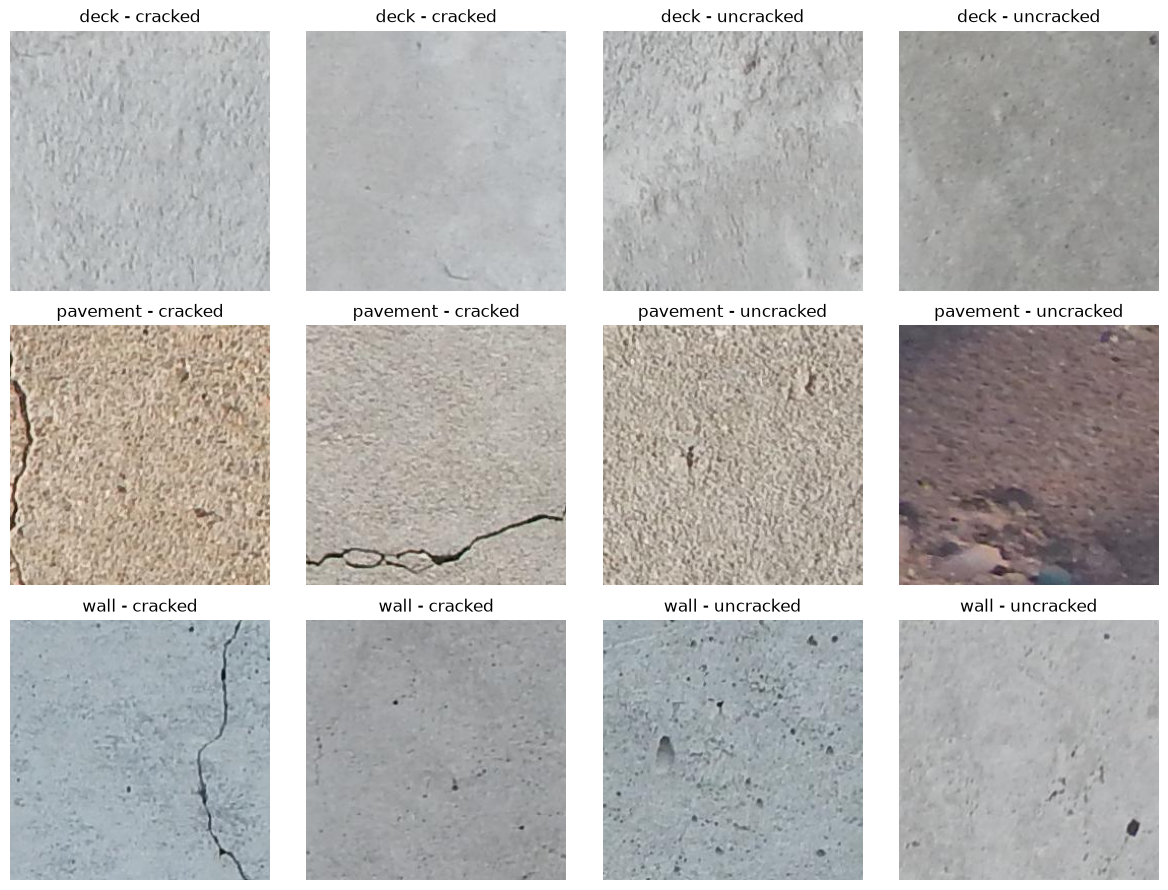

In [14]:
import matplotlib.pyplot as plt
from PIL import Image

# Select representative images
samples = metadata.groupby(["surface", "label"], group_keys=False).sample(
    n=2,
    random_state=42
)

# Display images
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, (_, row) in zip(axes.ravel(), samples.iterrows()):
    image = Image.open(row["image_path"])
    
    ax.imshow(image)
    ax.set_title(f"{row['surface']} - {row['label']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
import numpy as np
from PIL import Image

# Sample images
sample_metadata = metadata.sample(n=300, random_state=42)

quality_records = []

for _, row in sample_metadata.iterrows():
    image = np.array(Image.open(row["image_path"]).convert("RGB"))
    
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    quality_records.append({
        "image_path": row["image_path"],
        "surface": row["surface"],
        "label": row["label"],
        "width": image.shape[1],
        "height": image.shape[0],
        "channels": image.shape[2],
        "mean_intensity": gray.mean(),
        "std_intensity": gray.std()
    })

quality_df = pd.DataFrame(quality_records)

print("Sample size:", len(quality_df))
print("\nImage dimensions:")
print(quality_df[["width", "height", "channels"]].drop_duplicates())

print("\nIntensity statistics:")
print(
    quality_df[
        ["mean_intensity", "std_intensity"]
    ].describe()
)

Sample size: 300

Image dimensions:
   width  height  channels
0    256     256         3

Intensity statistics:
       mean_intensity  std_intensity
count      300.000000     300.000000
mean       163.006387      14.493606
std         20.274495       9.958509
min         69.578445       2.193005
25%        153.717125       7.424401
50%        165.530609      10.963750
75%        177.089561      19.696361
max        221.317780      59.432723


In [16]:
# Create a balanced sample

balanced_sample = (
    metadata.groupby(["surface", "label"], group_keys=False)
    .sample(n=50, random_state=42)
)

quality_records = []

for _, row in balanced_sample.iterrows():
    image = np.array(Image.open(row["image_path"]).convert("RGB"))
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    
    quality_records.append({
        "surface": row["surface"],
        "label": row["label"],
        "mean_intensity": gray.mean(),
        "std_intensity": gray.std()
    })

balanced_quality = pd.DataFrame(quality_records)

print("Number of images:", len(balanced_quality))

print("\nMean intensity by surface and class:")
print(
    balanced_quality
    .groupby(["surface", "label"])["mean_intensity"]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)

print("\nIntensity standard deviation by surface and class:")
print(
    balanced_quality
    .groupby(["surface", "label"])["std_intensity"]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)

Number of images: 300

Mean intensity by surface and class:
                      mean    std     min     max
surface  label                                   
deck     cracked    177.31  10.47  124.79  191.29
         uncracked  176.51  12.42  110.15  193.92
pavement cracked    155.95  21.84   86.60  221.91
         uncracked  148.04  29.64   54.42  184.00
wall     cracked    172.15   9.91  151.74  188.92
         uncracked  167.72   9.99  144.12  188.41

Intensity standard deviation by surface and class:
                     mean    std    min    max
surface  label                                
deck     cracked    11.22   8.85   4.76  64.92
         uncracked   7.27   3.34   3.93  26.21
pavement cracked    27.09   9.11  11.78  50.22
         uncracked  23.90  10.07   4.56  53.66
wall     cracked     9.39   4.94   3.37  32.64
         uncracked   9.28   6.01   2.08  38.69


# final preprocessing

In [1]:
import torch
from torchvision import transforms

# Define final preprocessing
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(preprocess)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [17]:
# Select test images
test_samples = metadata.groupby("label", group_keys=False).sample(
    n=1,
    random_state=42
)

for _, row in test_samples.iterrows():
    image = Image.open(row["image_path"]).convert("RGB")
    tensor_image = preprocess(image)
    
    print(f"\nLabel: {row['label']}")
    print("Original size:", image.size)
    print("Tensor shape:", tensor_image.shape)
    print("Tensor dtype:", tensor_image.dtype)
    print("Tensor range:", 
          tensor_image.min().item(), 
          "to", 
          tensor_image.max().item())


Label: cracked
Original size: (256, 256)
Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tensor range: -1.5185376405715942 to 1.942832350730896

Label: uncracked
Original size: (256, 256)
Tensor shape: torch.Size([3, 224, 224])
Tensor dtype: torch.float32
Tensor range: -0.4739275872707367 to 2.395991325378418


### Split Data

In [19]:
from sklearn.model_selection import train_test_split

# Create stratification label
metadata["stratify_group"] = (
    metadata["surface"] + "_" + metadata["label"]
)

# Split training set
train_df, temp_df = train_test_split(
    metadata,
    test_size=0.30,
    random_state=42,
    stratify=metadata["stratify_group"]
)

# Split validation and test sets
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["stratify_group"]
)

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Training: 39264
Validation: 8414
Test: 8414


### data distribution

In [20]:
# Check class and surface distribution

for name, df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name}")
    print("-" * len(name))
    
    print("\nClass distribution:")
    print(df["label"].value_counts())
    
    print("\nSurface distribution:")
    print(df["surface"].value_counts())
    
    print("\nSurface × class distribution:")
    print(
        pd.crosstab(
            df["surface"],
            df["label"]
        )
    )


Training
--------

Class distribution:
label
uncracked    33325
cracked       5939
Name: count, dtype: int64

Surface distribution:
surface
pavement    17034
wall        12697
deck         9533
Name: count, dtype: int64

Surface × class distribution:
label     cracked  uncracked
surface                     
deck         1417       8116
pavement     1826      15208
wall         2696      10001

Validation
----------

Class distribution:
label
uncracked    7141
cracked      1273
Name: count, dtype: int64

Surface distribution:
surface
pavement    3650
wall        2721
deck        2043
Name: count, dtype: int64

Surface × class distribution:
label     cracked  uncracked
surface                     
deck          304       1739
pavement      391       3259
wall          578       2143

Test
----

Class distribution:
label
uncracked    7142
cracked      1272
Name: count, dtype: int64

Surface distribution:
surface
pavement    3650
wall        2720
deck        2044
Name: count, dtype: int64

In [21]:
# Remove temporary stratification column

train_df = train_df.drop(columns=["stratify_group"])
val_df = val_df.drop(columns=["stratify_group"])
test_df = test_df.drop(columns=["stratify_group"])

# Save dataset splits
train_df.to_csv("../data/metadata/train.csv", index=False)
val_df.to_csv("../data/metadata/validation.csv", index=False)
test_df.to_csv("../data/metadata/test.csv", index=False)

print("Dataset splits saved successfully.")

Dataset splits saved successfully.


In [22]:
# Verify saved splits

for file_name in ["train.csv", "validation.csv", "test.csv"]:
    path = Path("../data/metadata") / file_name
    df = pd.read_csv(path)
    
    print(f"{file_name}: {len(df)} rows")

train.csv: 39264 rows
validation.csv: 8414 rows
test.csv: 8414 rows
